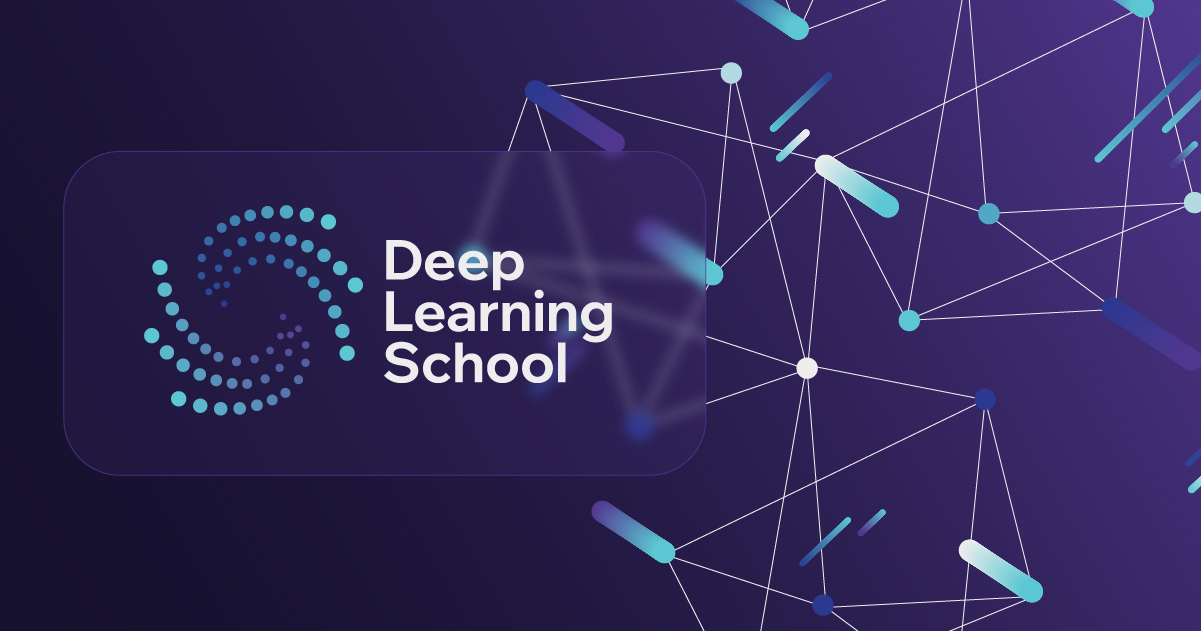


<h3 style="text-align: center;"><b>"Глубокое обучение". Продвинутый поток</b></h3>

<h1 style="text-align: center;"><b>Семинар. PyTorch. Оптимизаторы. </b></h1>


In [1]:
# !pip install tqdm

In [2]:
from __future__ import print_function, division
import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, datasets
from tqdm.notebook import tqdm
import random

c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [3]:
# Зафиксируем сиды для воспроизводимости
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [4]:
# Выберем cuda или cpu
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

# Загрузка датасета

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) — это набор данных, состоящий из 60 000 цветных изображений размером $32 \times 32$ пикселя, разделённых на 10 классов (например, самолёты, автомобили, птицы, кошки и др.). Из них 50 000 изображений используются для обучения моделей, а 10 000 — для их тестирования. Этот датасет широко применяется в задачах компьютерного зрения и отлично подходит для экспериментов с PyTorch.


In [5]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def get_dataloaders(batch_size):
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    trainset = datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                              shuffle=True, num_workers=2)
    testset = datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                             shuffle=False, num_workers=2)
    return trainloader, testloader

В PyTorch датасетом считается любой объект, для которого определены методы `__len__(self)` и `__getitem__(self, i)`.

# Код обучения

In [6]:
def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
    train_losses = []
    val_losses = []
    valid_accuracies = []
    for epoch in range(epochs):
        model.train() # Set model to training mode
        loss_sum = 0
        for xb, yb in tqdm(train_dl):
            # Move data to the appropriate device
            xb, yb = xb.to(device), yb.to(device)

            # Forward pass
            preds = model(xb)
            loss = loss_func(preds, yb)

            # Accumulate loss
            loss_sum += loss.item()

            # Backpropagation
            loss.backward()
            opt.step()
            opt.zero_grad()
        train_losses.append(loss_sum / len(train_dl))

        model.eval() # set model in validation mode
        loss_sum = 0
        correct = 0
        num = 0
        # for validation we don't need calculate gradients
        # ! eval() mode doen't turn off gradients !
        with torch.no_grad(): 
            for xb, yb in valid_dl:
                xb, yb = xb.to(device), yb.to(device)
                probs = model(xb)
                loss_sum += loss_func(probs, yb).item()

                _, preds = torch.max(probs, axis=-1)
                correct += (preds == yb).sum().item()
                num += len(xb)

        val_losses.append(loss_sum / len(valid_dl))
        valid_accuracies.append(correct / num)

    return train_losses, val_losses, valid_accuracies

In [7]:
def plot_trainig(train_losses, valid_losses, valid_accuracies):
    plt.figure(figsize=(12, 9))

    # Plot training and validation losses in the first subplot
    plt.subplot(2, 1, 1)
    plt.xlabel('epoch')
    plt.plot(train_losses, label='train_loss')
    plt.plot(valid_losses, label='valid_loss')
    plt.legend()

    # Plot validation accuracy in the second subplot
    plt.subplot(2, 1, 2)
    plt.xlabel('epoch')
    plt.plot(valid_accuracies, label='valid accuracy')
    plt.legend()

In [8]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square conv kernel
        self.conv1 = nn.Conv2d(3, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)  # 5x5 image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Далее мы запускаем обучение модели:
- Определяем функцию потерь ([CrossEntropyLoss](https://colab.research.google.com/drive/1EOlgKwXSj9z7JqBl9sz2Xg-pfv2Xjw7e#scrollTo=RQygJ0ZHCgCK&line=2&uniqifier=1)) и оптимизатор ([SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) с параметрами $\text{lr}=0.001$ и $\text{momentum}=0.9$).
- Запускаем обучение модели на $10$ эпох с помощью функции `fit` и визуализируем результаты (графики потерь и точности) с помощью plot_training.

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

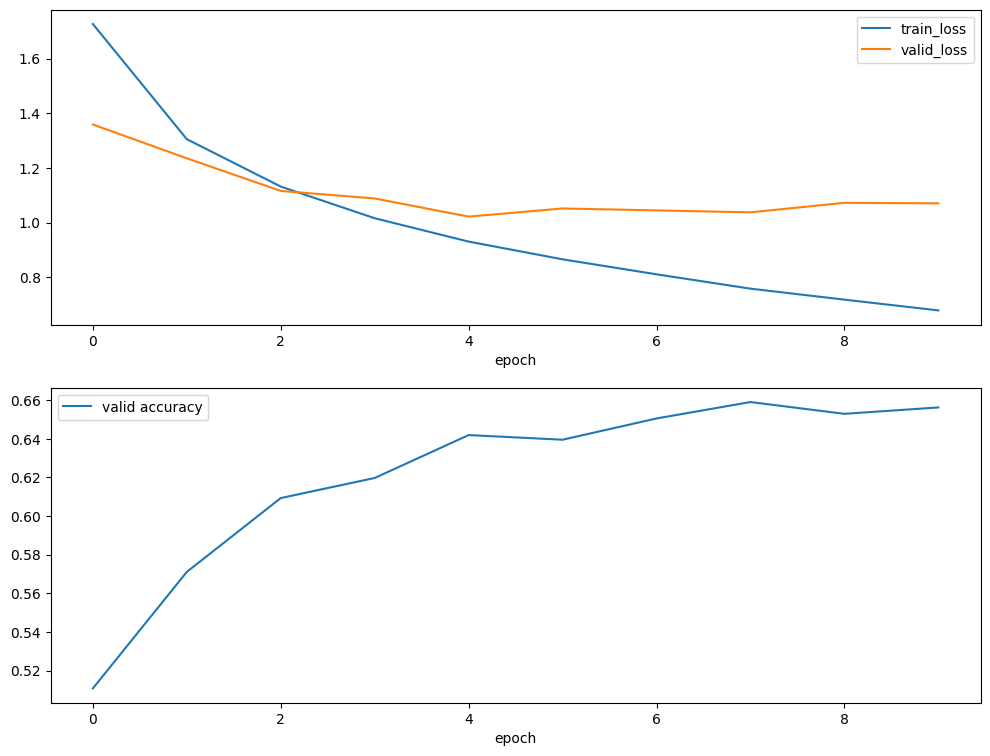

In [9]:
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

info = fit(10, model, criterion, optimizer, *get_dataloaders(4))
plot_trainig(*info)

# Adam

Это самый популярный оптимизатор для нейронных сетей. Если вам интересны сравнения разных алгоритмов, то можете почитать эту статью https://arxiv.org/abs/1609.04747.

### Adam, применение в PyTorch

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

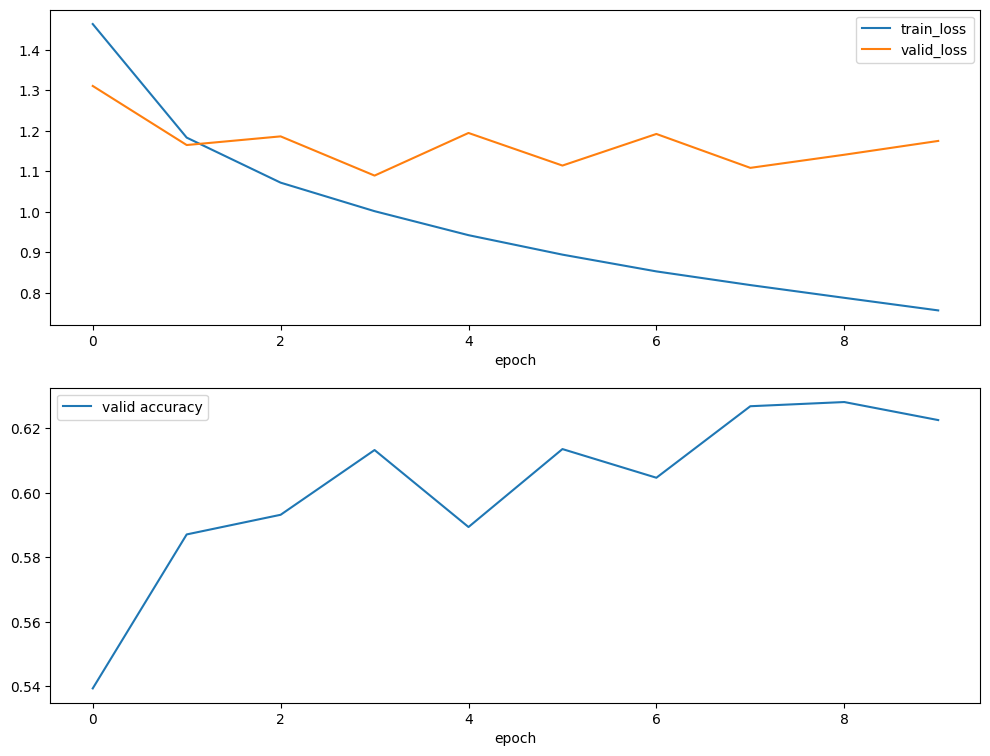

In [10]:
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))

info = fit(10, model, criterion, optimizer, *get_dataloaders(4))
plot_trainig(*info)

# Weight Decay

Для регуляризации линейных моделей мы прибавляли к лоссу сумму квадратов весов, умноженных на некоторый коэффициент:
$$L(\mathbf{w})=\sum_{i=1}^{l}\left(\mathbf{x}_{i}^{T} \mathbf{w}-y_{i}\right)^{2}+\beta \sum_{j=1}^{n} w_{j}^{2}$$

Для нейронных сетей мы можем выбрать такую же реугляризацию. Она называется WeightDecay. Во многие оптимизаторы можно передать параметр `weight_decay` и он будет являться коэффициентом, на который домножается сумма квадратовв весов.

Обычно используют `weight_decay=0.01` или `0.005`.

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

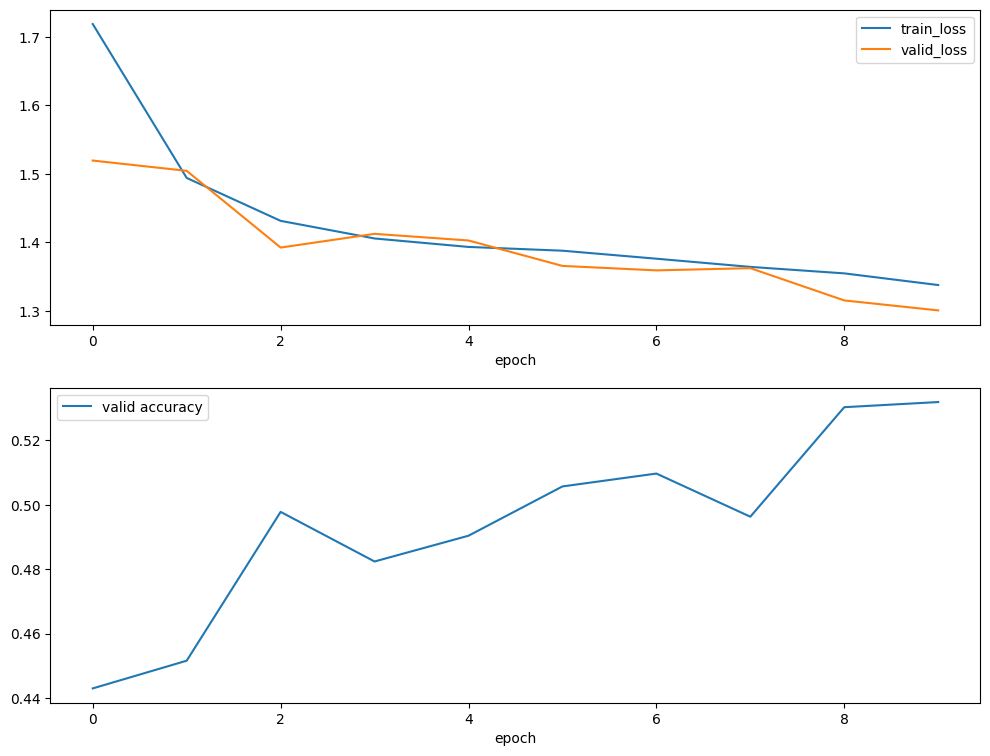

In [11]:
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999), weight_decay=0.01)

info = fit(10, model, criterion, optimizer, *get_dataloaders(4))
plot_trainig(*info)

# LR scheduling

Часто мы хотим, чтобы наш learning rate как-то изменялся во время обучения. Стратегия, по которой мы будем изменять `lr` называется **lr scheduilng**.

Например, мы можем хотеть, чтобы learning_rate уменьшался с каждой эпохой в фиксированное число раз. Тогда в начале мы будем быстро двигаться к минимуму, а в конце точно не промахнемся мимо него за счет малых шагов. Такая стратегия называется LR Decay.
![](https://www.deeplearningwizard.com/deep_learning/boosting_models_pytorch/images/lr2.png)

(Слева используется lr decay, справа нет. Слева мы можем не подбирать идеально точно lr и все равно со временем сойтись.)

Нам нужно немного изменить train loop

In [14]:
def fit(epochs, model, loss_func, opt, train_dl, valid_dl, lr_sched=None):
    train_losses = []
    val_losses = []
    valid_accuracies = []
    for epoch in range(epochs):
        model.train()
        loss_sum = 0
        for xb, yb in tqdm(train_dl):
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_func(model(xb), yb)
            loss_sum += loss.item()

            loss.backward()
            opt.step()
            opt.zero_grad()
        train_losses.append(loss_sum / len(train_dl))

        model.eval()
        loss_sum = 0
        correct = 0
        num = 0
        with torch.no_grad():
            for xb, yb in valid_dl:
                xb, yb = xb.to(device), yb.to(device)
                probs = model(xb)
                loss_sum += loss_func(probs, yb).item()

                _, preds = torch.max(probs, axis=-1)
                correct += (preds == yb).sum().item()
                num += len(xb)

        val_losses.append(loss_sum / len(valid_dl))
        valid_accuracies.append(correct / num)

        # CHANGES HERE
        if lr_sched is not None:
            lr_sched.step()
        # CHANGES END

    return train_losses, val_losses, valid_accuracies

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

  0%|          | 0/12500 [00:00<?, ?it/s]

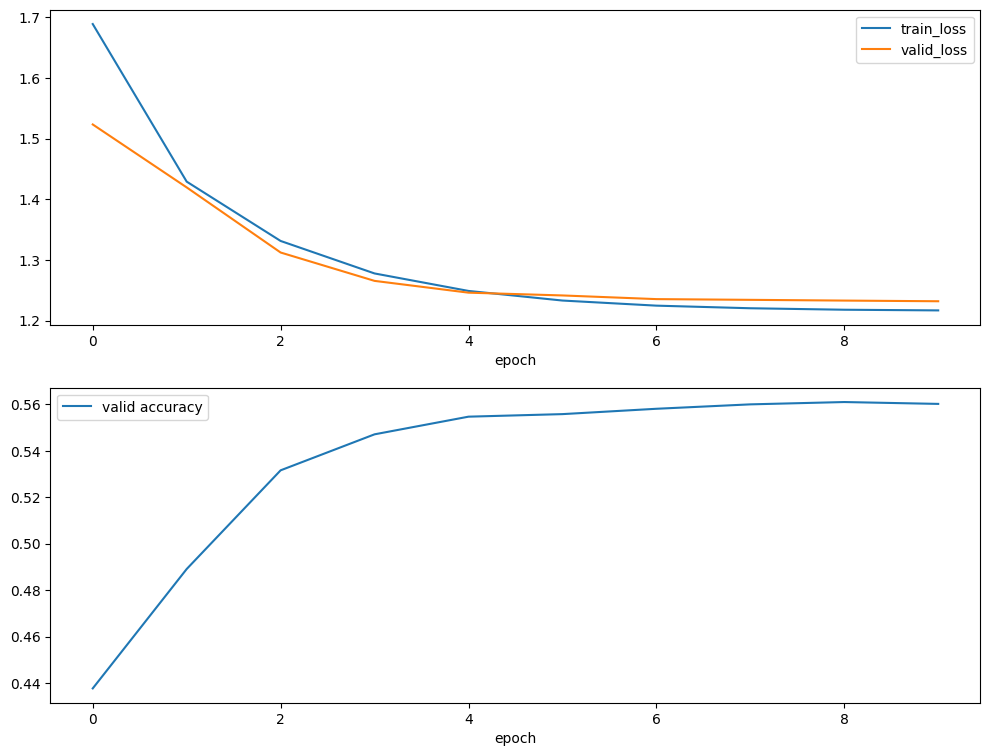

In [13]:
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999), weight_decay=0.01)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=0.5)

info = fit(10, model, criterion, optimizer, *get_dataloaders(4), scheduler)
plot_trainig(*info)

# Чекпоинтинг.

Есть очень хорошее официальное руководство: https://pytorch.org/tutorials/beginner/saving_loading_models.html.

## Сохранение и загрузка модели для вывода

In [ ]:
# Словарь параметров: слои, веса, смещения, в том числе настройки оптимизатора

# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

# Print optimizer's state_dict
print("Optimizer's state_dict:")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

Model's state_dict:
conv1.weight 	 torch.Size([6, 3, 3, 3])
conv1.bias 	 torch.Size([6])
conv2.weight 	 torch.Size([16, 6, 3, 3])
conv2.bias 	 torch.Size([16])
fc1.weight 	 torch.Size([120, 576])
fc1.bias 	 torch.Size([120])
fc2.weight 	 torch.Size([84, 120])
fc2.bias 	 torch.Size([84])
fc3.weight 	 torch.Size([10, 84])
fc3.bias 	 torch.Size([10])
Optimizer's state_dict:
state 	 {0: {'step': tensor(125000.), 'exp_avg': tensor([[[[-0.0274, -0.0263, -0.0210],
          [-0.0225, -0.0265, -0.0270],
          [-0.0239, -0.0270, -0.0300]],

         [[-0.0249, -0.0235, -0.0186],
          [-0.0206, -0.0232, -0.0244],
          [-0.0231, -0.0244, -0.0270]],

         [[-0.0168, -0.0148, -0.0102],
          [-0.0130, -0.0149, -0.0174],
          [-0.0160, -0.0165, -0.0207]]],


        [[[-0.0031,  0.0128,  0.0147],
          [-0.0010,  0.0074,  0.0077],
          [-0.0043, -0.0032, -0.0009]],

         [[-0.0011,  0.0176,  0.0167],
          [-0.0006,  0.0093,  0.0084],
          [-0.0077, -

In [ ]:
# !mkdir models

In [26]:
# Сохранение словаря с параметрами модели

import os

PATH = 'models'
save_path = os.path.join(PATH, 'model_weights.pth')
torch.save(model.state_dict(), save_path)

In [ ]:
# Загрузка

model_load = Model().to(device)
model_load.load_state_dict(torch.load(save_path, weights_only=True))
model_load.eval()

Model(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## Сохранить/загрузить всю модель

In [ ]:
# Сохранение

save_path = os.path.join(PATH, 'model_lr.pt')
torch.save(model, save_path)

In [ ]:
# Загрузка

model = torch.load(save_path, weights_only=False)
model.eval()

Model(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## Сохранение и загрузка общей контрольной точки для вывода и/или возобновления обучения

In [ ]:
# # Сохранение

# save_path = os.path.join(PATH, 'model_checkpont.pt')

# torch.save({
#             'epoch': epoch,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'loss': loss,
#             ...
#             }, save_path)

In [ ]:
# # Загрузка

# model = Model().to(device=device)
# optimizer = Model(*args, **kwargs)

# checkpoint = torch.load(save_path, weights_only=True)
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# epoch = checkpoint['epoch']
# loss = checkpoint['loss']

# model.eval()
# # - or -
# model.train()